In [ ]:
#Numpy used for data manipulation and setting up the environent for the models
import numpy as np
import pandas as pd
print("Numpy version:", np.__version__)

#Adjustable values for data testing
#----------------------------------
DATA = 5000
NEURALS = 64
#-----------------------------------

#This is initialization of simple dataset
X_train = np.random.rand(DATA, 1)
y_train = (X_train > 0.7).astype(int)

print(f"Dataset creatded with {len(X_train)} DATA.")


X = np.linspace(0,10, DATA).reshape(-1,1)

#Linear Regression data environment
#simple y = mx +b
"""Linear Equation """ 
y_linear = 2 * X + np.random.normal(0, 1, (DATA,1))

#Curved Regression data environment
# now using y = ax^2 +sin(x) + noise, adding complexity
"""Curved Equation """ 
y_curved = 0.5 * X**2 + np.sin(X) + np.random.normal(0, 2, (DATA,1))


#applied variable and model calculations here
stage_a = X * np.cos(0.5 *X)
stage_b = np.sin(stage_a)
stage_c = np.sign(np.sin(X)) * 0.5

#noise adds unpredictibility for models to calculate
noise = np.random.normal(0, 0.5, (DATA,1))

"""Chained Equation """ 
y_chain = stage_a + stage_b + stage_c + noise


#Used a tuple dictionary to draw prediction and latency values
model_par_results = {}
results_data = {
    "Model": ["Sequential", "Parallel", "Modular"],
    "Linear_Loss": [(0,0), (0,0), (0,0)],
    "Curved_Loss": [(0,0), (0,0), (0,0)],
    "Chain_Loss":  [(0,0), (0,0), (0,0)],
}


#Iterative environmens with test scenarios
environments = {
    "Linear": y_linear.astype('float32'),
    "Curved": y_curved.astype('float32'),
    "Chain": y_chain.astype('float32')
}

df_results = pd.DataFrame(results_data).set_index("Model")

print("Linear, Curved, and Chained regression datasets ready")


Numpy version: 2.0.2
Dataset creatded with 5000 DATA.
Linear, Curved, and Chained regression datasets ready


In [ ]:
#Errors happens because tensorflow not able to understand environment
#actually being ran inside the Google Colab T4 GPU, which supports tensorflow
import tensorflow as tf
from tensorflow.keras import layers
import time

#Model 1: Sequential Order

#model is called by instantiating from Keras and adding layers within

# Training and timing the process

history_sequential_log = {env: [] for env in environments.keys()}

#iteration through each environment
for name, scenario in environments.items():
    model_seq = tf.keras.Sequential([
        #Input layer
        layers.Input((1,)),
        layers.Dense(NEURALS, activation='relu'),
        layers.Dense(NEURALS, activation='relu'),
        #Used for ending/combination
        layers.Dense(1)
    ])

    model_seq.compile(optimizer='adam', loss='mse')

    tf.keras.backend.clear_session()
    start_time = time.perf_counter()

    # NOTE: Use a larger batch_size to speed up training if X_train is large

    #Real logic behind traning and getting data from model
    #setting up length(epochs), training, and other consisten scenarios
    history = model_seq.fit(
        X_train, 
        scenario, 
        epochs=100, 
        batch_size=32,  # Process 32 rows at once instead of 1
        verbose=0,
        shuffle=False   # Shuffling takes extra time; turn off for speed
    )

    _ =  model_seq.predict(X_train[:1])

    #Measuring the time by subtracting initial with last period htel
    train_time = time.perf_counter() - start_time

    #Getting every single epoch period's MSE value
    history_sequential_log[name].append(history.history['loss'])

    
    #Getting the LAST value of history log --> therefore [-1]
    loss_history = history.history['loss'][-1]

    #This is our data framework logic that takes the FINAL loss value(MSE) as well as
    #time to be measured in the table
    df_results.at["Sequential", f"{name}_Loss"] = (loss_history, train_time)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:


import tensorflow as tf
from tensorflow.keras import layers
import time
#Model 2: Parallel Structuring

#format of how layers going to receive data
inputs = layers.Input(shape=(1,))

#this is our first layer of the parallel structure
branch_a = layers.Dense(NEURALS, activation='relu')(inputs)

#this is our second layer of the parallel structure
branch_b = layers.Dense(NEURALS, activation='relu')(inputs)

merged = layers.concatenate([branch_a, branch_b])

outputs = layers.Dense(1)(merged)

#This instantiates the model that we call from keras while handling
#input-output scenarios
modelparallel = tf.keras.Model(inputs=inputs, outputs=outputs)

#IMPORTANT: We are using Adam Optimizer to allow all models to run in consistent environments, while also
modelparallel.compile(optimizer='adam', loss='mse')

history_parallel_log = {env: [] for env in environments.keys()}

#iteration through each environment
for name, scenario in environments.items():


    start_train = time.perf_counter()
    
    # NOTE: Use a larger batch_size to speed up training if X_train is large

    #Real logic behind traning and getting data from model
    #setting up length(epochs), training, and other consisten scenarios
    history = modelparallel.fit(
        X_train, 
        scenario.astype('float32'), 
        epochs=100, 
        batch_size=32,  
        verbose=0,
        shuffle=False   
    )
    
    train_time = time.perf_counter() - start_time

    history_parallel_log[name] = history.history['loss']

    loss_history = history.history['loss'][-1]

    #This is our data framework logic that takes the FINAL loss value(MSE) as well as
    #time to be measured in the table
    df_results.at["Parallel", f"{name}_Loss"] = (loss_history, train_time)




In [ ]:
import torch

#Instead of declaring model directly we must create a class and call it in pytorch
class Modularnet(torch.nn.Module):
    def __init__(self, NEURAL_VALUE):

        super(Modularnet, self).__init__()
        self.b1 = torch.nn.Linear(1,NEURAL_VALUE)
        self.b2 = torch.nn.Linear(NEURAL_VALUE,1)

    def forward(self,x):

        #start first prcessing layer
        x = self.b1(x)

        #testing layer b1
        x = torch.relu(x)

        #testing layer b2
        x = self.b2(x)

        return x



history_mod_log = {env: [] for env in environments.keys()}

for name, scenario in environments.items():
    start_time = time.perf_counter()
    target_sensor = torch.from_numpy(scenario.astype(np.float32))
    inputs_t = torch.from_numpy(X_train).float()

    modular_network = Modularnet(NEURALS)
    optimizer = torch.optim.Adam(modular_network.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()


    #needed specifically for pytorch as there is no supported function to iterate
    #through each epoch
    for epoch in range(100):
        modular_network.train()

        outputs = modular_network(inputs_t)
        loss = criterion(outputs, target_sensor)


        #note how we log each epoch to graph later in matplotlib
        history_mod_log[name].append(loss.item())   

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    final_loss = loss.item()
    train_time = time.perf_counter() - start_time

    
    
    df_results.at["Modular", f"{name}_Loss"] = (final_loss, train_time)


    mod_seq = df_results.loc[("Modular", "Linear_Loss")]
    


Text(0.5, 1.0, 'Chained Regression Data')

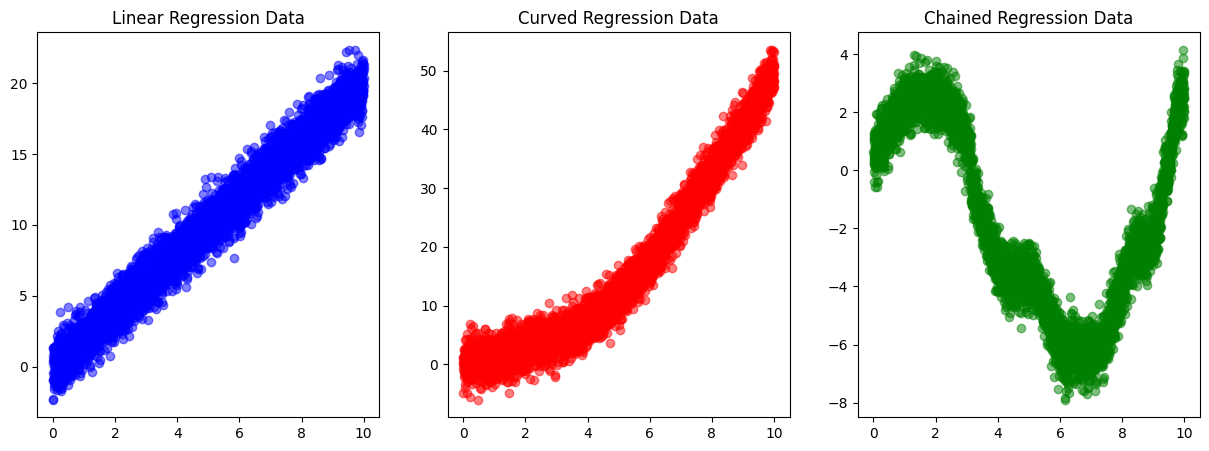

In [5]:
#Control Group: visualization of datasets
from matplotlib import pyplot as plt

plt.figure(figsize=(15,5))

#blue corresponds to the linear regression data
plt.subplot(1,3,1)
plt.scatter(X, y_linear, color='blue', alpha=0.5)
plt.title("Linear Regression Data")

#red corresponds to the curved regression data
plt.subplot(1,3,2)
plt.scatter(X, y_curved, color='red', alpha=0.5)
plt.title("Curved Regression Data")

#green corresponds to the chained regression data
plt.subplot(1,3,3)
plt.scatter(X, y_chain, color='green', alpha=0.5)
plt.title("Chained Regression Data")

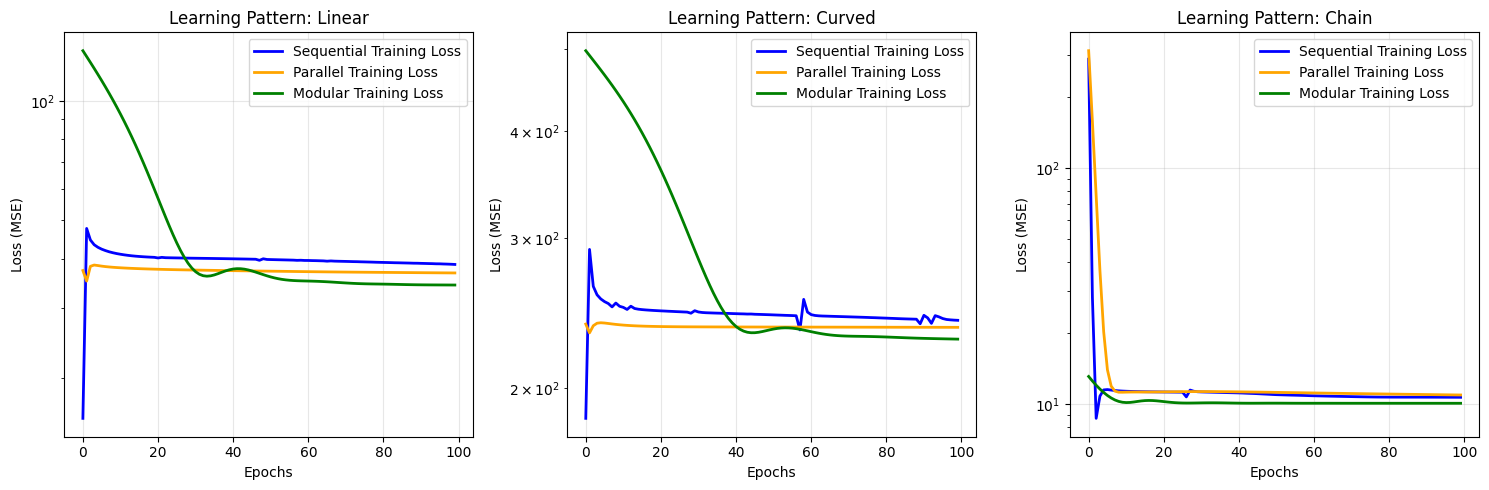

In [6]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 5))

#iteration list
envs = ["Linear", "Curved", "Chain"]


for i, env_name in enumerate(envs):
    #going through each model instance and graphing them separately with epoch logs
    plt.subplot(1, 3, i + 1)

    
    plt.plot(history_sequential_log[env_name], label='Sequential Training Loss', color='blue', linewidth=2)
    plt.plot(history_parallel_log[env_name], label='Parallel Training Loss', color='orange', linewidth=2)
    plt.plot(history_mod_log[env_name], label='Modular Training Loss', color='green', linewidth=2)
    
    #customizations for detail on graph(X Title, Y title, etc.)
    plt.title(f"Learning Pattern: {env_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.yscale('log') # Keep log to see the fine-tuning at the end
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


In [7]:
display(df_results)
# Through a tuple dictionary, we can see both the loss and training time for each model and scenario
#dictionrary key: (Time, Prediction Rate(MSE))

,Linear_Loss,Curved_Loss,Chain_Loss
Model,,,
Sequential,"(38.668704986572266, 34.68635111199998)","(240.3281707763672, 32.03061644599998)","(10.702463150024414, 32.74048997099999)"
Parallel,"(36.803466796875, 66.44831048199998)","(235.8168182373047, 97.91535429999999)","(10.94620418548584, 130.03544925900002)"
Modular,"(34.305416107177734, 7.1846660319999955)","(228.440673828125, 0.19959154499997567)","(10.096992492675781, 0.22429461400002992)"
